In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
from skimage import data,io

from skimage.color import rgb2hsv
from scipy import ndimage, misc

C:\Users\Admin\AppData\Local\Temp\ipykernel_2916\1342986733.py:8: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import ndimage, misc


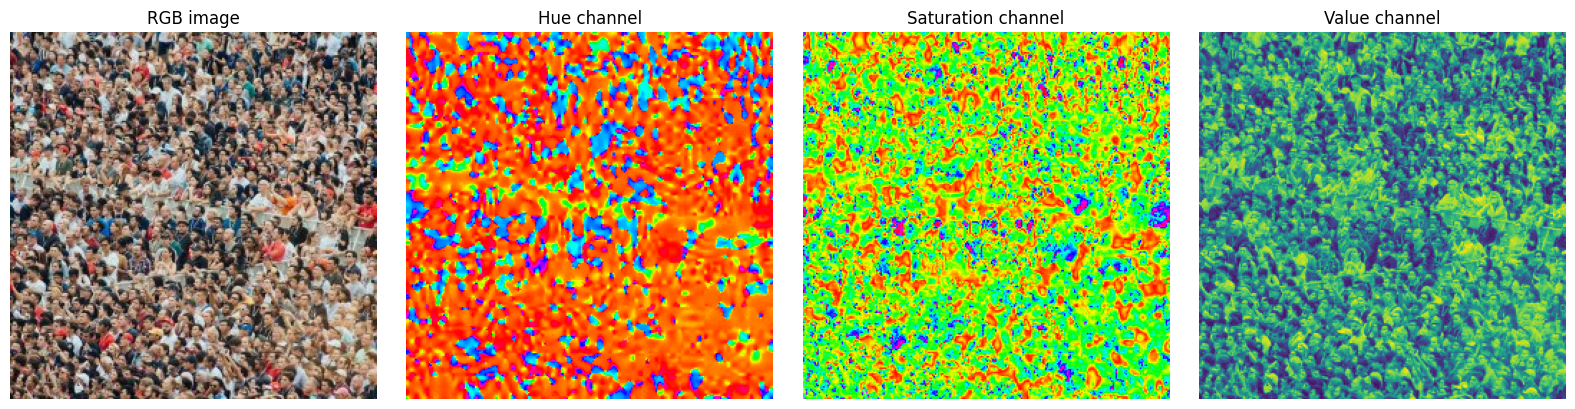

In [2]:
rgb_img = data.coffee()

rgb_img = io.imread('Wisdom-of-crowds.jpg')
hsv_img = rgb2hsv(rgb_img)
hue_img = hsv_img[:, :, 0]
sat_img = hsv_img[:, :, 1]
value_img = hsv_img[:, :, 2]

fig, (ax0, ax1, ax2, ax3) = plt.subplots(ncols=4, figsize=(16, 4))

ax0.imshow(rgb_img)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(hue_img, cmap='hsv')
ax1.set_title("Hue channel")
ax1.axis('off')
ax2.imshow(sat_img, cmap='hsv')
ax2.set_title("Saturation channel")
ax2.axis('off')
ax3.imshow(value_img)
ax3.set_title("Value channel")
ax3.axis('off')

fig.tight_layout()

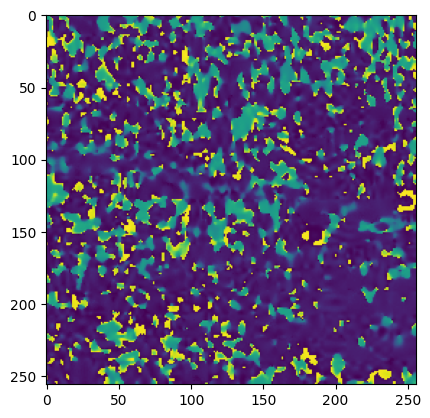

In [3]:
gauss = ndimage.gaussian_filter(hue_img, sigma=1/3)
plt.imshow(gauss)

In [4]:
print(hue_img)
print(sat_img)

[[0.57526882 0.57801418 0.61111111 ... 0.05333333 0.08139535 0.08974359]
 [0.57692308 0.57916667 0.59803922 ... 0.0530303  0.07916667 0.09375   ]
 [0.58080808 0.58024691 0.61538462 ... 0.05952381 0.08080808 0.08333333]
 ...
 [0.03333333 0.07291667 0.08024691 ... 0.56349206 0.59195402 0.59313725]
 [0.23809524 0.16666667 0.10416667 ... 0.58333333 0.62179487 0.63333333]
 [0.35       0.21212121 0.13194444 ... 0.58333333 0.63580247 0.66091954]]
[[0.88571429 0.64383562 0.12328767 ... 0.49019608 0.37719298 0.29885057]
 [0.86666667 0.75471698 0.12230216 ... 0.39285714 0.37037037 0.2962963 ]
 [0.76744186 0.49090909 0.07514451 ... 0.11382114 0.30841121 0.33870968]
 ...
 [0.35714286 0.47058824 0.25961538 ... 0.38888889 0.6744186  0.53968254]
 [0.4375     0.52631579 0.30769231 ... 0.40816327 0.56521739 0.57692308]
 [0.47619048 0.84615385 0.32432432 ... 0.4        0.31395349 0.46774194]]


In [5]:
def rad2complex(I):
    I_tilde = np.exp(1j*I)
    return I_tilde

def angular_diff(t1, t2):
    ans = (t2-t1+np.pi) % (2*np.pi) - np.pi
    return ans

def wrap_index(U,V,w,h):
    u = U
    v = V
    if U>=h:
        u= U-h
        
    if V>=w:
        v = V-w
        
    return u,v

def LoG_I(Ih_tilde, Is, r, alpha):
    w = Is.shape[1]
    h = Is.shape[0]
    
    I_gauss_r = ndimage.gaussian_filter(np.real(Ih_tilde), sigma=1/3)
    I_gauss_i = ndimage.gaussian_filter(np.imag(Ih_tilde), sigma=1/3)
    I_gauss = I_gauss_r + 1j*I_gauss_i
    
    LoGI = np.zeros((h,w))
    for u in range(h):
        for v in range(w):
            s = 0
            for U in range(u-r, u+r+1):
                for V in range(v-r, v+r+1):
#                     s = s + angular_diff(I_gauss[U,V], I_gauss[u,v]) * (Is[u,v] * Is[U,V])**alpha
                    U_wrap,V_wrap = wrap_index(U,V,w,h)
                    s = s + angular_diff(np.angle(I_gauss[U_wrap,V_wrap]), np.angle(I_gauss[u,v])) * (Is[u,v] * Is[U_wrap,V_wrap])**alpha
                    
            LoGI[u,v] = s
            
    return LoGI

def feat_1(Ih, Is, r):
    alpha = 0.25
    Ih_tilde = rad2complex(Ih)
    LoGI = LoG_I(Ih_tilde, Is, r, alpha)
    feat = ndimage.gaussian_filter(LoGI, sigma=r/3)
    
    return feat

def feat_2():
    

def binary_img(I_h, k):
    

IndentationError: expected an indented block after function definition on line 50 (620701582.py, line 53)

In [ ]:
# Ih_tilde = rad2complex(hue_img)
# r=3
# LoGI = LoG_I(Ih_tilde, sat_img, r, 0.25)

# plt.imshow(LoGI)

feat1 = feat_1(hue_img, sat_img, 3)
plt.imshow(feat1)